In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
from cns.process.binning import add_cns_loc, group_bins, sum_cns
from cns.display.plot import plot_lines, fig_lines
from cns.data_utils import  load_filter_samples, load_filter_bins, get_cns_for_type

In [3]:
samples = load_filter_samples()

In [4]:
cns = load_filter_bins(samples, "10MB")

In [5]:
samples["PCAWG"]["TCGA_type"].value_counts()[:6]

TCGA_type
LIRI    250
PACA    233
PBCA    230
BRCA    211
PRAD    158
OV      110
Name: count, dtype: int64

In [6]:
get_cns_for_type(cns["PCAWG"], samples["PCAWG"], "LUAD").head()

,sample_id,chrom,start,end,major_cn,minor_cn
0,SP50263,chr1,0,10127953,3.949543,0.050457
1,SP50263,chr1,10127953,20255906,4.000000,0.000000
2,SP50263,chr1,20255906,30383859,4.272085,0.000000
3,SP50263,chr1,30383859,40511811,3.428317,0.734227
4,SP50263,chr1,40511811,50639764,3.212776,0.787224


In [7]:
luad_dict = { k : get_cns_for_type(cns[k], samples[k], "LUAD") for k in cns.keys() }
lusc_dict = { k : get_cns_for_type(cns[k], samples[k], "LUSC") for k in cns.keys() }
means_single = [group_bins(dataset) for dataset in [v for k, v in luad_dict.items()] + [v for k, v in lusc_dict.items()]]
luad_all = pd.concat([v for k, v in luad_dict.items()])
lusc_all = pd.concat([v for k, v in lusc_dict.items()])
means_all = [group_bins(dataset) for dataset in [luad_all, lusc_all]]

In [14]:
means_single[0]

,cum_mid,chrom,start,end,mid,length,major_cn,minor_cn,total_cn
0,5063976,chr1,0,10127953,5063976,10127953,2.027833,1.058715,3.086548
1,15191929,chr1,10127953,20255906,15191929,10127953,1.981953,1.037484,3.019437
2,25319882,chr1,20255906,30383859,25319882,10127953,1.922425,1.073997,2.996421
3,35447835,chr1,30383859,40511811,35447835,10127952,1.950432,1.190850,3.141282
4,45575787,chr1,40511811,50639764,45575787,10127953,1.945178,1.191856,3.137034
...,...,...,...,...,...,...,...,...,...
285,3020697421,chrX,134461994,144866277,139664135,10404283,1.621325,0.451562,2.072887
286,3031101704,chrX,144866277,155270560,150068418,10404283,1.684825,0.442392,2.127217
287,3041356122,chrY,0,10104553,5052276,10104553,0.882353,0.000000,0.882353
288,3053337101,chrY,13104553,20961957,17033255,7857404,0.941065,0.000000,0.941065


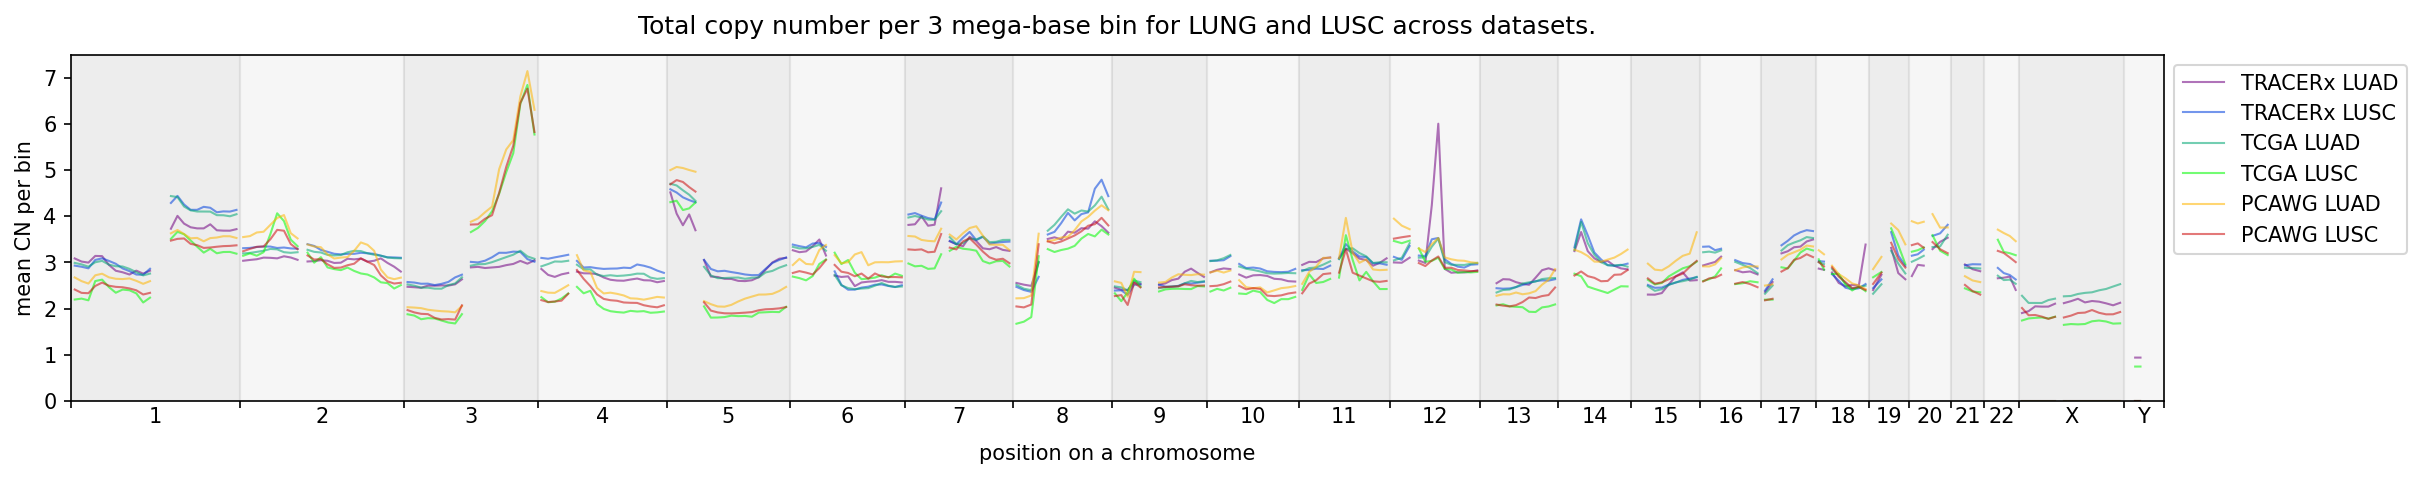

In [30]:
labels = ["TRACERx LUAD", "TRACERx LUSC", "TCGA LUAD", "TCGA LUSC", "PCAWG LUAD", "PCAWG LUSC"]
fig, ax = fig_lines(means_single, labels, column="total_cn", dpi=150)
ax.set_title("Total copy number per 3 mega-base bin for LUNG and LUSC across datasets.", pad=10)
plt.savefig("../../out/fig_LUAD_LUSC_single.pdf", bbox_inches='tight')

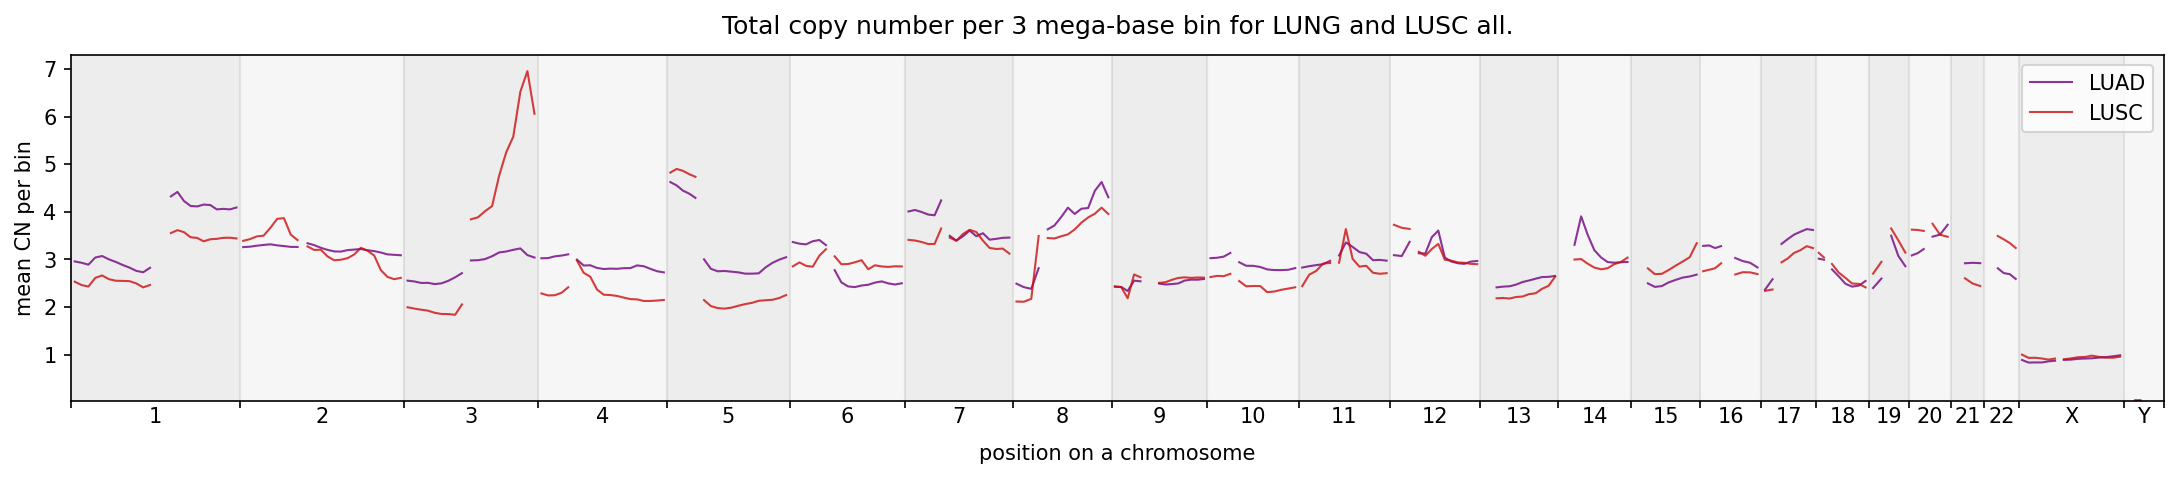

In [18]:
fig, ax = fig_lines(means_all, ["LUAD", "LUSC"], column="total_cn", dpi=150)
ax.set_title("Total copy number per 3 mega-base bin for LUNG and LUSC all.", pad=10)
plt.savefig("../../out/fig_LUAD_LUSC_all.pdf", bbox_inches='tight')

(<Figure size 1800x300 with 1 Axes>,
 <Axes: xlabel='position on a chromosome', ylabel='mean CN per bin'>)

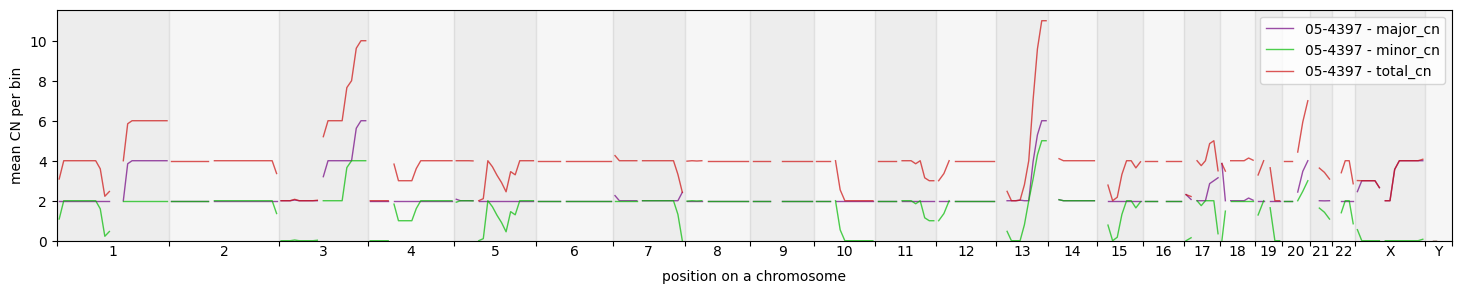

In [28]:
tracer_x_sel_ids = list(samples["TCGA"].query("type == 'LUAD'").index[9:10])

groups = []
for id in tracer_x_sel_ids:
	select_cns = cns["TCGA"].set_index("sample_id").loc[id].reset_index()
	groups.append(sum_cns(add_cns_loc(select_cns)))

shorten = [name[-7:] for name in tracer_x_sel_ids]
fig_lines(groups, shorten)

(0.0, 10.0)

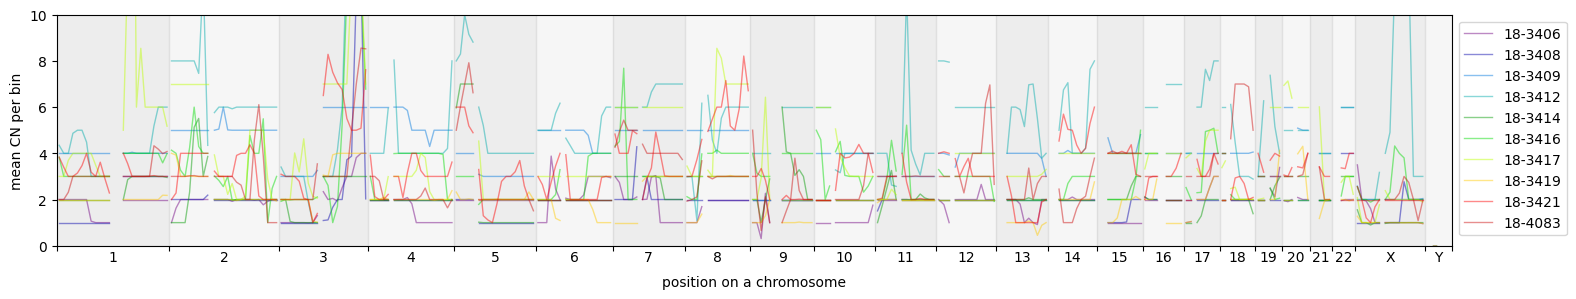

In [29]:
tracer_x_sel_ids = list(samples["TCGA"].query("type == 'LUSC'").index[:10])

groups = []
for id in tracer_x_sel_ids:
	select_cns = cns["TCGA"].set_index("sample_id").loc[id].reset_index()
	groups.append(sum_cns(add_cns_loc(select_cns)))

shorten = [name[-7:] for name in tracer_x_sel_ids]
fig, ax = fig_lines(groups, shorten, column="total_cn");
ax.set_ylim(0,10)